In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
from scipy.spatial.transform import Rotation as R
import pickle
import zarr
from diffusion_policy.common.replay_buffer import ReplayBuffer
from omegaconf import OmegaConf
from diffusion_policy.codecs.imagecodecs_numcodecs import register_codecs
from umi.common.pose_util import (
    pose_to_mat, mat_to_pose, 
    mat_to_pose10d, pose10d_to_mat)
from diffusion_policy.common.pose_repr_util import convert_pose_mat_rep
from ur_ikfast.ur_ikfast import ur_kinematics
from scipy.signal import savgol_filter


In [2]:
OmegaConf.register_new_resolver("eval", eval, replace=True)
register_codecs()

In [3]:
# zarr_path = '/home/soochul/GoPro_20250508/dataset.zarr.zip'
zarr_path = '/home/soochul/dataset0320.zarr.zip'
zip_store = zarr.ZipStore(zarr_path, mode='a')
root = zarr.group(zip_store)
replay_buffer = ReplayBuffer.create_from_group(root)
num_episodes = len(replay_buffer.episode_ends)
print(f"Loaded replay buffer with {num_episodes} episodes.")
episode_idx = np.random.choice(num_episodes)
print(f"Replaying episode {episode_idx}...")
ep = replay_buffer.get_episode(episode_idx)
# print(ep.keys()) 
# dict_keys(['camera0_rgb', 'robot0_demo_end_pose', 'robot0_demo_start_pose', 
# 'robot0_eef_pos', 'robot0_eef_rot_axis_angle', 
# 'robot0_force', 'robot0_gripper_width', 'robot0_torque'])
for robot_idx in range(1):
    pos_replay = ep[f'robot{robot_idx}_eef_pos'][:]
    rot_replay = ep[f'robot{robot_idx}_eef_rot_axis_angle'][:]
    grip_replay = ep[f'robot{robot_idx}_gripper_width'][:]
actions = np.concatenate([pos_replay, rot_replay, grip_replay], axis=-1)

Loaded replay buffer with 198 episodes.
Replaying episode 184...


In [8]:
cam_pose = np.concatenate([pos_replay, rot_replay], axis=-1)
cam_pose = pose_to_mat(cam_pose)
cam_pose.shape

(527, 4, 4)

In [9]:
tx_tag_tcp = cam_pose

In [10]:
tx_tag_base = np.array([
    [
      0.03211492248880736,
      -0.9994368845046818,
      -0.009723458495465576,
      0.030644970111311266
    ],
    [
      0.9984514101250388,
      0.03252236202704855,
      -0.045133995917751066,
      -0.6239592891696314
    ],
    [
      0.04542481010262852,
      -0.008258926065581207,
      0.9989336198003265,
      0.0661112935489998
    ],
    [
      0.0,
      0.0,
      0.0,
      1.0
    ]
    
    # [
    #   0.014500569635805594,
    #   -0.9997530090623589,
    #   -0.016842041176650398,
    #   -0.044059934138102635
    # ],
    # [
    #   0.9996692201244223,
    #   0.014853059193052465,
    #   -0.02099611793729384,
    #   -0.4799630648844079
    # ],
    # [
    #   0.02124108792096622,
    #   -0.016532014498134257,
    #   0.9996376887055468,
    #   -0.02314005620630681
    # ],
    # [
    #   0.0,
    #   0.0,
    #   0.0,
    #   1.0
    # ]
    
    #     [
    #   -0.9992668101498986,
    #   0.03786236221936187,
    #   0.005681871172127269,
    #   -0.018283582081895254
    # ],
    # [
    #   -0.03760656116820821,
    #   -0.998497334760624,
    #   0.03985999288801041,
    #   -0.49712673959771314
    # ],
    # [
    #   0.007182526710609295,
    #   0.03961709231001545,
    #   0.9991891198901993,
    #   -0.042018964151028
    # ],
    # [
    #   0.0,
    #   0.0,
    #   0.0,
    #   1.0
    # ]
  
  ])

tx_base_tag = np.linalg.inv(tx_tag_base)

In [11]:
tx_base_tcp = tx_base_tag @ tx_tag_tcp

In [12]:
base_tcp_pose = mat_to_pose(tx_base_tcp)

In [13]:
base_tcp_pose.shape

(527, 6)

In [14]:
tx_base_tcp[0]

array([[-0.152888  , -0.77180012,  0.61721132,  0.38091773],
       [-0.98791264,  0.10320175, -0.11566356,  0.07210487],
       [ 0.02557186, -0.62743439, -0.77824938,  0.35545163],
       [ 0.        ,  0.        ,  0.        ,  1.        ]])

In [15]:
ur3_arm = ur_kinematics.URKinematics('ur3')

joint_angles = [-3.1, -1.6, 1.6, -1.6, -1.6, 0.]  # in radians
print("joint angles", joint_angles)

pose_quat = ur3_arm.forward(joint_angles)
pose_matrix = ur3_arm.forward(joint_angles, 'matrix')

print("forward() quaternion \n", pose_quat)
print("forward() matrix \n", pose_matrix)

print("inverse() one from quat", ur3_arm.inverse(pose_quat, False, q_guess=joint_angles))

print("inverse() one from matrix", ur3_arm.inverse(pose_matrix, False, q_guess=joint_angles))


joint angles [-3.1, -1.6, 1.6, -1.6, -1.6, 0.0]
forward() quaternion 
 [-0.28901327 -0.12208153  0.31610811 -0.69627027 -0.02465703  0.71734233
 -0.00444365]
forward() matrix 
 [[-0.03037599  0.04071115 -0.99870914 -0.28901327]
 [ 0.02796067 -0.99874455 -0.04156303 -0.12208153]
 [-0.99914742 -0.0291871   0.02919955  0.31610811]]
inverse() one from quat [-3.09999990e+00 -1.60000002e+00  1.60000002e+00 -1.59999990e+00
 -1.60000002e+00  8.12307910e-09]
inverse() one from matrix [-3.09999990e+00 -1.60000002e+00  1.60000002e+00 -1.60000002e+00
 -1.60000002e+00  3.58920644e-08]


In [16]:
num_ur3_joints = 6
ep_length = tx_base_tcp.shape[0]
timesteps = np.arange(ep_length)

joint_trajectory = np.zeros((ep_length, num_ur3_joints))

for t, pose in enumerate(tx_base_tcp):
    curr_pose = pose[:3, :4]
    if t != 0:
        joint_trajectory[t, :] = ur3_arm.inverse(curr_pose, False, q_guess=joint_trajectory[t-1, :])
    else:
        joint_trajectory[t, :] = ur3_arm.inverse(curr_pose, False)

joint_trajectory.shape

(527, 6)

In [17]:
if np.any(np.isnan(joint_trajectory)):
    print("obs joint contains NaN")
else:
    print("No none")

obs joint contains NaN


In [24]:
def smooth_trajectory(trajectory, window_length=100, polyorder=7):
    # Ensure the window length is odd
    if window_length % 2 == 0:
        window_length += 1
    # If there are too few points, adjust the window_length accordingly.
    if trajectory.shape[0] < window_length:
        window_length = trajectory.shape[0] if trajectory.shape[0] % 2 == 1 else trajectory.shape[0] - 1
    return savgol_filter(trajectory, window_length, polyorder, axis=0)

In [18]:
def plot_joint_trajectory(joint_trajectory, timesteps, num_ur3_joints):
    fig, axs = plt.subplots(num_ur3_joints, 1, figsize=(10, 2 * num_ur3_joints), sharex=True)
    
    for joint in range(num_ur3_joints):
        axs[joint].plot(timesteps, joint_trajectory[:, joint], linestyle='-')
        axs[joint].set_title(f'Joint {joint + 1}')
        axs[joint].set_ylabel('Angle (radians)')
        axs[joint].grid(True)
    
    axs[-1].set_xlabel('Timesteps')
    plt.tight_layout()
    plt.show()

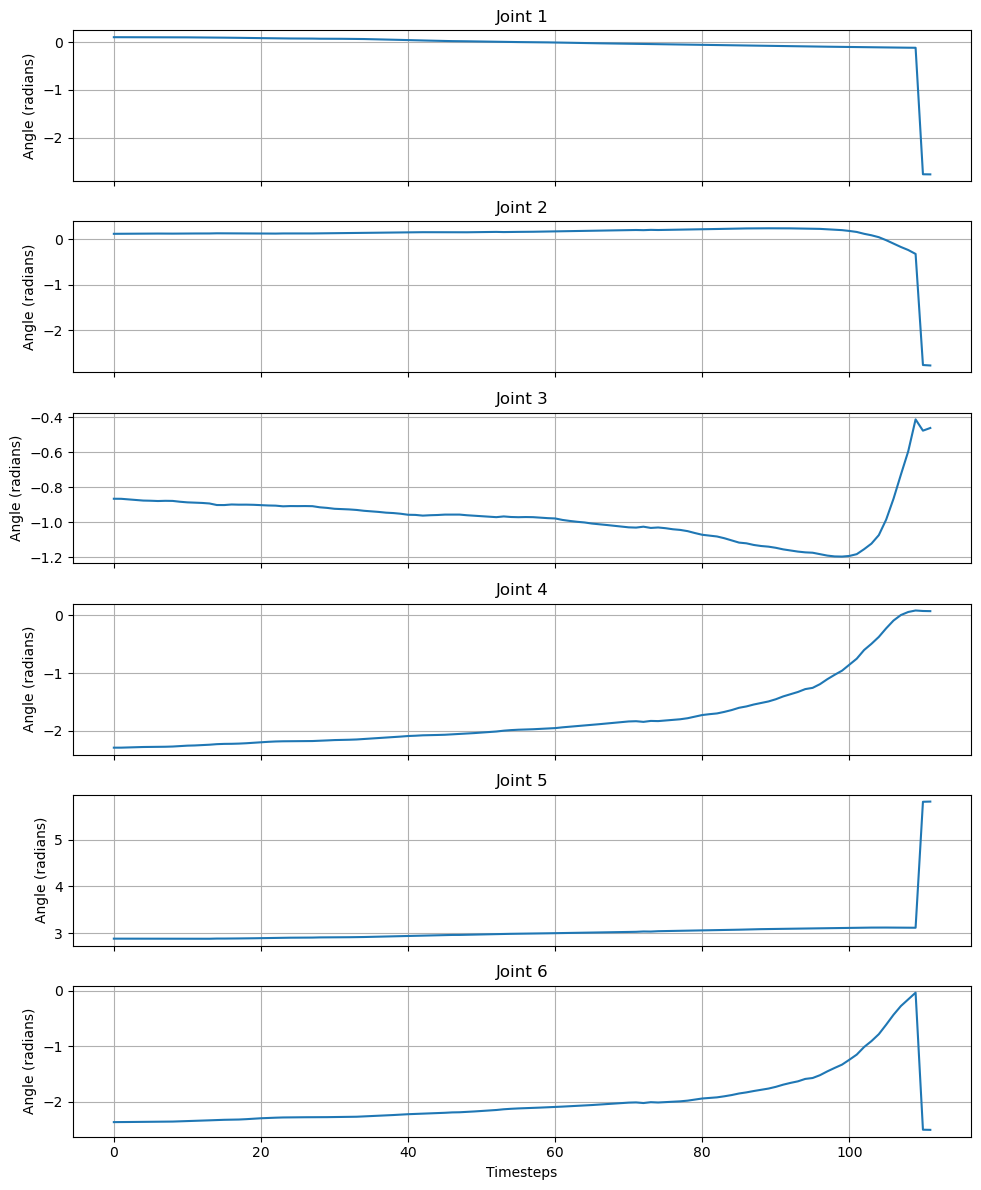

In [19]:
plot_joint_trajectory(joint_trajectory, timesteps, num_ur3_joints)

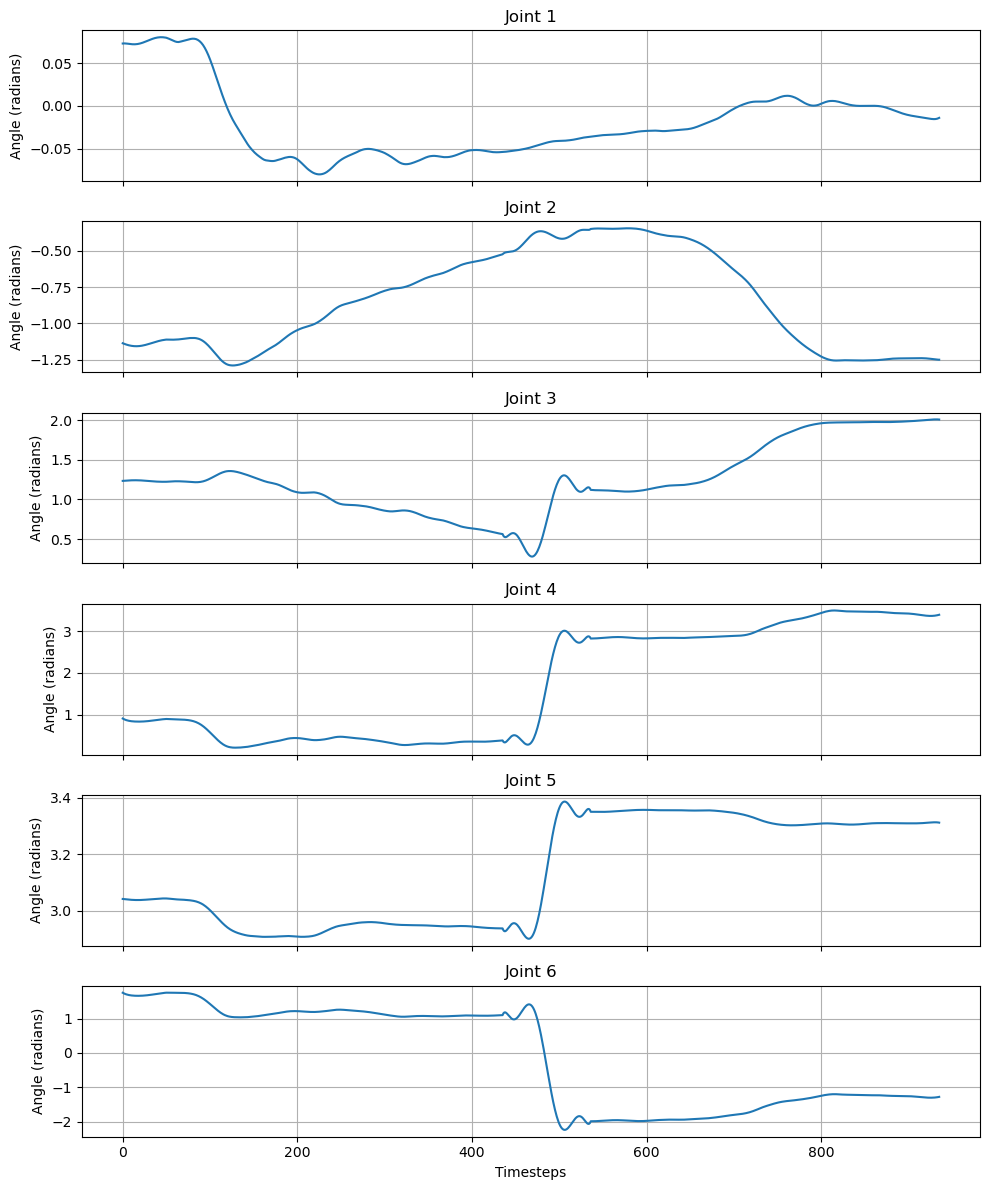

In [25]:
smooth_joint_trajectory = smooth_trajectory(joint_trajectory)
plot_joint_trajectory(smooth_joint_trajectory, timesteps, num_ur3_joints)

In [ ]:
def add_traces(fig, T, scale=0.05, marker_color='black', marker_size=2):
    origin = T[:3, 3]
    R = T[:3, :3]
    fig.add_trace(go.Scatter3d(
        x=[origin[0]], y=[origin[1]], z=[origin[2]],
        mode='markers',
        marker=dict(size=marker_size, color=marker_color),
        showlegend=False
    ))

def plot_traj(cam_pose):
    fig = go.Figure()
    n_frames = cam_pose.shape[0]
    subsample = 1  

    for i in range(0, n_frames, subsample):
        T = cam_pose[i]
        if i == 0:
            color = 'green'  # start frame
            size = 6
        elif i == n_frames - 1:
            color = 'red'    # end frame
            size = 6
        else:
            color = 'black'
            size = 2
        add_traces(fig, T, scale=0.05, marker_color=color, marker_size=size)

    fig.update_layout(
        scene=dict(aspectmode='data'),
        title="All Camera Poses (Frames)"
    )
    fig.show()

In [ ]:
pose_trajectory = np.zeros((ep_length, 4, 4))


for t, q in enumerate(joint_trajectory):
    pose_trajectory[t, :3, :4] = ur3_arm.forward(q, rotation_type='matrix')

pose_trajectory.shape

In [ ]:
plot_traj(pose_trajectory)

In [ ]:
plot_traj(tx_base_tcp)

In [ ]:
def similarity_check(original_pose, converted_pose):
    diff = np.linalg.inv(original_pose) @ converted_pose

    p_diff = diff[:3, 3]
    pos_err = np.linalg.norm(p_diff)

    R_diff = diff[:3, :3]
    trace_val = np.trace(R_diff)
    cos_angle = (trace_val - 1.0) / 2.0
    cos_angle = max(min(cos_angle, 1.0), -1.0)
    rot_err = np.arccos(cos_angle)

    return pos_err, rot_err


In [ ]:
errors = np.zeros((ep_length, 2))
for t in range(ep_length):
    pos_error, rot_error = (similarity_check(tx_base_tcp[t], pose_trajectory[t]))
    errors[t, 0] = pos_error
    errors[t, 1] = rot_error

In [ ]:
errors

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(10, 2))

for ax in range(2):
    axs[ax].plot(timesteps, errors[:, ax], linestyle='-')
    axs[ax].grid(True)

axs[-1].set_xlabel('Timesteps')
plt.tight_layout()
plt.show()

In [22]:
# zarr_path = '/home/soochul/GoPro_20250117/dataset.zarr.zip' #  good: 12 bad: 193 total: 205 => same
# zarr_path = '/home/soochul/GoPro_20250313/dataset.zarr.zip' # good:42 bad: 23 total: 65 => start offset => bad: 21
# zarr_path = '/home/soochul/GoPro_20250509/dataset.zarr.zip' # bad: 169 total:298 => tx_tag_base => bad: 36
zarr_path = '/home/soochul/GoPro_20250410/dataset.zarr.zip' # bad: 64 total:188 => tx_tag_base => bad: 138
# zarr_path = '/home/soochul/GoPro_20250410/dataset_with_ik.zarr.zip' # bad: 64 total:127
# zarr_path = '/home/soochul/GoPro_20250508/dataset.zarr.zip' # bad:  total:198 => tx_tag_base => bad: 24
# zarr_path = '/home/soochul/dataset0320.zarr.zip'



zip_store = zarr.ZipStore(zarr_path, mode='a')
root = zarr.group(zip_store)
replay_buffer = ReplayBuffer.create_from_group(root)
num_episodes = len(replay_buffer.episode_ends)
print(f"Loaded replay buffer with {num_episodes} episodes.")

ur3_arm = ur_kinematics.URKinematics('ur3')

num_ur3_joints = 6


tx_tag_base = np.array([
    [
      0.03211492248880736,
      -0.9994368845046818,
      -0.009723458495465576,
      0.030644970111311266
    ],
    [
      0.9984514101250388,
      0.03252236202704855,
      -0.045133995917751066,
      -0.6239592891696314
    ],
    [
      0.04542481010262852,
      -0.008258926065581207,
      0.9989336198003265,
      0.0661112935489998
    ],
    [
      0.0,
      0.0,
      0.0,
      1.0
    ]

    # [
    #   0.014500569635805594,
    #   -0.9997530090623589,
    #   -0.016842041176650398,
    #   -0.044059934138102635
    # ],
    # [
    #   0.9996692201244223,
    #   0.014853059193052465,
    #   -0.02099611793729384,
    #   -0.4799630648844079
    # ],
    # [
    #   0.02124108792096622,
    #   -0.016532014498134257,
    #   0.9996376887055468,
    #   -0.02314005620630681
    # ],
    # [
    #   0.0,
    #   0.0,
    #   0.0,
    #   1.0
    # ]
  
  ])

tx_base_tag = np.linalg.inv(tx_tag_base)

nan_items = 0
start_offset = 0.0

for episode_idx in range(num_episodes):
    ep = replay_buffer.get_episode(episode_idx)
    for robot_idx in range(1):
        pos_replay = ep[f'robot{robot_idx}_eef_pos'][:]
        rot_replay = ep[f'robot{robot_idx}_eef_rot_axis_angle'][:]
        grip_replay = ep[f'robot{robot_idx}_gripper_width'][:]
    actions = np.concatenate([pos_replay, rot_replay, grip_replay], axis=-1)

    cam_pose = np.concatenate([pos_replay, rot_replay], axis=-1)
    cam_pose = pose_to_mat(cam_pose)
    tx_tag_tcp = cam_pose
    tx_base_tcp = tx_base_tag @ tx_tag_tcp

    ep_length = tx_base_tcp.shape[0]
    ep_start = int(ep_length * start_offset)
    timesteps = np.arange(ep_length - ep_start)
    joint_trajectory = np.zeros((ep_length - ep_start, num_ur3_joints))

    for t, pose in enumerate(tx_base_tcp[ep_start:]):
      curr_pose = pose[:3, :4]
      if t != 0:
          joint_trajectory[t, :] = ur3_arm.inverse(curr_pose, False, q_guess=joint_trajectory[t-1, :])
      else:
          joint_trajectory[t, :] = ur3_arm.inverse(curr_pose, False)

      if np.any(np.isnan(joint_trajectory)):
          print(f"joint contains NaN at {t} / {ep_length} with episode {episode_idx}")
          # print(joint_trajectory[t-3:t+1, :])
          nan_items += 1
          break

print(f"number of invalid episodes are {nan_items} in total {num_episodes} episodes")

    

Loaded replay buffer with 188 episodes.
joint contains NaN at 80 / 886 with episode 0
joint contains NaN at 14 / 896 with episode 1
joint contains NaN at 272 / 941 with episode 2
joint contains NaN at 215 / 823 with episode 3
joint contains NaN at 231 / 870 with episode 4
joint contains NaN at 270 / 971 with episode 5
joint contains NaN at 168 / 781 with episode 6
joint contains NaN at 45 / 836 with episode 7
joint contains NaN at 0 / 845 with episode 8
joint contains NaN at 236 / 703 with episode 9
joint contains NaN at 242 / 685 with episode 10
joint contains NaN at 279 / 808 with episode 11
joint contains NaN at 203 / 722 with episode 12
joint contains NaN at 135 / 688 with episode 13
joint contains NaN at 188 / 633 with episode 14
joint contains NaN at 16 / 656 with episode 15
joint contains NaN at 236 / 648 with episode 16
joint contains NaN at 24 / 602 with episode 17
joint contains NaN at 202 / 614 with episode 18
joint contains NaN at 62 / 526 with episode 19
joint contains NaN